# Slum Area Classification — Remote Sensing Model

Binary classification of **Slum (1)** vs **Non-Slum (0)** at the *kelurahan* level across
four Indonesian cities (Ambon, DKI Jakarta, Kebumen, Samarinda) using **XGBoost**.

The model fuses three complementary remote-sensing sources:

- **Building footprint** morphology (Google Open Buildings) — size, density, height, coverage.
- **Built-up spectral + texture** indices (Sentinel-2 NDBI and its GLCM texture).
- **Radar backscatter** (Sentinel-1 VV/VH) and **optical context** (NDVI, BSI, brightness).

### Pipeline at a glance
1. Load the per-kelurahan feature table and define the predictive feature groups.
2. Explore the data: class balance, feature relationships, spatial patterns.
3. Validate with **Leave-One-City-Out (LOCO)** cross-validation to measure how well the
   model generalizes to a city it has not seen during training.
4. Report imbalance-aware performance, inspect feature importance, and map predicted risk.

## 1. Imports

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from IPython.display import display

from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, roc_auc_score, roc_curve,
                             precision_recall_curve, accuracy_score, f1_score,
                             precision_score, recall_score)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
PALETTE = {0: '#2ecc71', 1: '#e74c3c'}

## 2. Data Loading & Feature Definition

The feature table holds one row per kelurahan. Predictive features are organized into four
source groups. Identifier and grouping columns (`unit_id`, `unit_area_m2`, `city`) are kept
separate from the model inputs: `city` defines the spatial grouping used by cross-validation,
while `unit_id` and `unit_area_m2` are metadata used for joining and reference only.

In [61]:
df = pd.read_csv('../data/processed/features_buildings.csv')

META = ['slum', 'city', 'unit_id', 'unit_area_m2']

CORE_BUILDING = [
    'b_area_mean', 'b_area_median', 'b_area_std', 'b_area_sum',
    'b_count', 'b_coverage', 'b_density_km2', 'b_size_cv',
    'building_fractional_count_mean', 'building_fractional_count_stdDev',
    'building_height_mean', 'building_height_stdDev',
    'building_presence_mean', 'building_presence_stdDev',
]
NDBI_BUILTUP = [
    'ndbi_mean', 'ndbi_stdDev', 'ndbi_contrast_mean', 'ndbi_contrast_stdDev',
    'ndbi_ent_mean', 'ndbi_ent_stdDev', 'ndbi_var_mean', 'ndbi_var_stdDev',
]
SAR_SENTINEL1 = ['VH_mean', 'VH_stdDev', 'VV_mean', 'VV_stdDev', 'vv_vh_mean', 'vv_vh_stdDev']
OPTICAL_INDICES = ['brightness_mean', 'brightness_stdDev', 'bsi_mean', 'bsi_stdDev',
                   'ndvi_mean', 'ndvi_stdDev']

GROUPS = {
    'Building footprint (Google Open Buildings)': CORE_BUILDING,
    'NDBI built-up + texture (Sentinel-2)': NDBI_BUILTUP,
    'SAR radar (Sentinel-1)': SAR_SENTINEL1,
    'Optical indices (Sentinel-2)': OPTICAL_INDICES,
}

FEATURES = [c for c in (CORE_BUILDING + NDBI_BUILTUP + SAR_SENTINEL1 + OPTICAL_INDICES)
            if c in df.columns]
feat_group = {f: g for g, cols in GROUPS.items() for f in cols}

y = df['slum'].astype(int).values
groups = df['city'].values

overview = pd.DataFrame({
    'group': list(GROUPS.keys()) + ['TOTAL'],
    'n_features': [len([c for c in cols if c in df.columns]) for cols in GROUPS.values()]
                  + [len(FEATURES)],
})
display(overview)
display(pd.Series({
    'n_samples': len(y), 'n_slum': int(y.sum()),
    'prevalence': round(float(y.mean()), 4), 'n_cities': int(len(np.unique(groups))),
}).to_frame('value'))

,group,n_features
0,Building footprint (Google Open Buildings),14
1,NDBI built-up + texture (Sentinel-2),8
2,SAR radar (Sentinel-1),6
3,Optical indices (Sentinel-2),6
4,TOTAL,34


,value
n_samples,828.0000
n_slum,118.0000
prevalence,0.1425
n_cities,4.0000


## 2.5 Feature Engineering

Beyond the raw measurements we derive a small set of **ratio and interaction features** that
describe the *structure* of a settlement rather than its absolute scale. Because they are
built from each kelurahan's own values (no city-level statistics), they carry the same
meaning in every city and therefore **transfer across cities** under Leave-One-City-Out
validation. They are designed to capture morphological signatures of informal settlements:

- **Small-building dominance** — many tiny structures relative to the average size.
- **Dense low-rise signature** — high building density combined with low building height.
- **Tight packing** — built-up coverage relative to building count and size.
- **Built-up vs vegetation contrast** — strong built-up index with little greenery.
- **Roof / radar heterogeneity** — irregular roof texture and radar roughness.

The new features are added to the feature set and flow through the rest of the analysis.

In [62]:
# Derived, city-transferable features (computed per row -> safe for LOCO, no leakage).
eps = 1e-6

# Small-building dominance: informal areas have many small structures vs the mean.
if {'b_area_median', 'b_area_mean'}.issubset(df.columns):
    df['b_area_med_mean_ratio'] = df['b_area_median'] / (df['b_area_mean'] + eps)
# Tight packing: built-up coverage spread over many buildings.
if {'b_coverage', 'b_count'}.issubset(df.columns):
    df['b_coverage_per_count'] = df['b_coverage'] / (df['b_count'] + eps)
# Dense low-rise signature: high density, low height -> classic informal settlement.
if {'b_density_km2', 'building_height_mean'}.issubset(df.columns):
    df['density_lowrise'] = df['b_density_km2'] / (df['building_height_mean'] + eps)
# Packing relative to footprint size: tightly packed small buildings.
if {'b_coverage', 'b_area_mean'}.issubset(df.columns):
    df['coverage_per_area'] = df['b_coverage'] / (df['b_area_mean'] + eps)
# Built-up strength vs vegetation: built-up with little greenery.
if {'ndbi_mean', 'ndvi_mean'}.issubset(df.columns):
    df['ndbi_minus_ndvi'] = df['ndbi_mean'] - df['ndvi_mean']
# Roof heterogeneity: texture relative to built-up level.
if {'ndbi_contrast_mean', 'ndbi_mean'}.issubset(df.columns):
    df['ndbi_texture_ratio'] = df['ndbi_contrast_mean'] / (df['ndbi_mean'].abs() + eps)
# Radar roughness: VH vs VV backscatter contrast.
if {'VH_mean', 'VV_mean'}.issubset(df.columns):
    df['vh_vv_diff'] = df['VH_mean'] - df['VV_mean']

ENGINEERED = [c for c in [
    'b_area_med_mean_ratio', 'b_coverage_per_count', 'density_lowrise',
    'coverage_per_area', 'ndbi_minus_ndvi', 'ndbi_texture_ratio', 'vh_vv_diff',
] if c in df.columns]

# Divisions can produce inf; convert to NaN so the pipeline's median imputer handles them.
df[ENGINEERED] = df[ENGINEERED].replace([np.inf, -np.inf], np.nan)

GROUP_ENGINEERED = 'Engineered (ratios + interactions)'
GROUPS[GROUP_ENGINEERED] = ENGINEERED
feat_group.update({f: GROUP_ENGINEERED for f in ENGINEERED})
FEATURES = list(dict.fromkeys(FEATURES + ENGINEERED))

display(pd.DataFrame({'engineered_feature': ENGINEERED,
                      'corr_with_slum': [round(float(df[f].corr(df['slum'])), 3) for f in ENGINEERED]}))
print(f'Added {len(ENGINEERED)} engineered features. Total features now: {len(FEATURES)}')

,engineered_feature,corr_with_slum
0,b_area_med_mean_ratio,-0.290
1,b_coverage_per_count,0.058
2,density_lowrise,-0.155
3,coverage_per_area,0.293
4,ndbi_minus_ndvi,0.299
5,ndbi_texture_ratio,0.095
6,vh_vv_diff,-0.101


Added 7 engineered features. Total features now: 41


## 3. Exploratory Data Analysis

Each visualization below is framed by the question it is meant to answer, so the analysis
reads as a guided investigation of the data.

### 3.1 Class balance and per-city prevalence
**Question:** How many kelurahan are slums versus non-slums, and does the slum rate differ
from city to city? This sets the imbalance level and motivates city-aware validation.

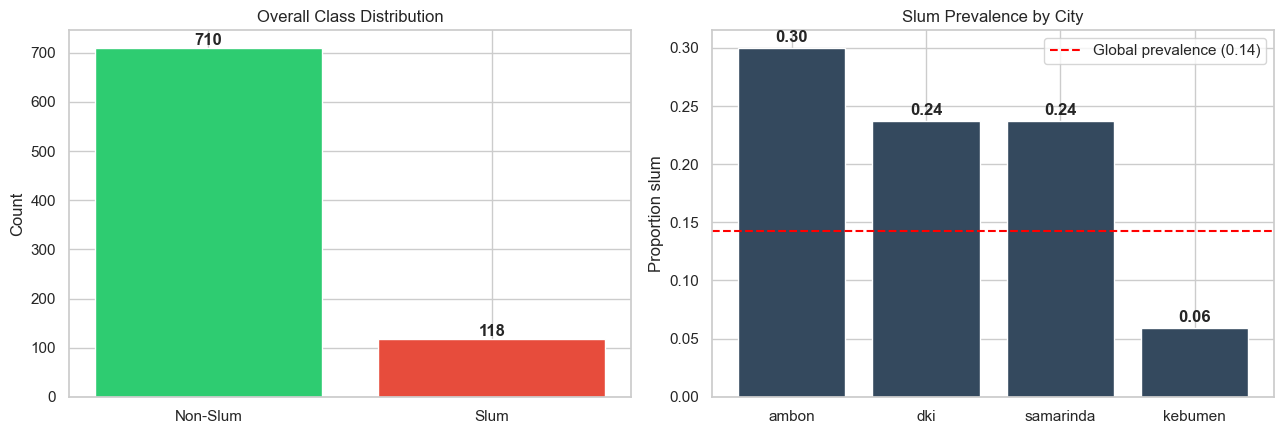

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

counts = pd.Series(y).map({0: 'Non-Slum', 1: 'Slum'}).value_counts()
ax[0].bar(counts.index, counts.values, color=[PALETTE[0], PALETTE[1]])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
ax[0].set_title('Overall Class Distribution')
ax[0].set_ylabel('Count')

prev = df.groupby('city')['slum'].mean().sort_values(ascending=False)
ax[1].bar(prev.index, prev.values, color='#34495e')
ax[1].axhline(y.mean(), ls='--', color='red', label=f'Global prevalence ({y.mean():.2f})')
for i, v in enumerate(prev.values):
    ax[1].text(i, v + 0.005, f'{v:.2f}', ha='center', fontweight='bold')
ax[1].set_title('Slum Prevalence by City')
ax[1].set_ylabel('Proportion slum')
ax[1].legend()
plt.tight_layout()
plt.show()

### 3.2 Which features relate to slum status?
**Question:** Which individual features show the strongest linear association with the slum
label, and which data source do they come from? Bars are colored by source group.

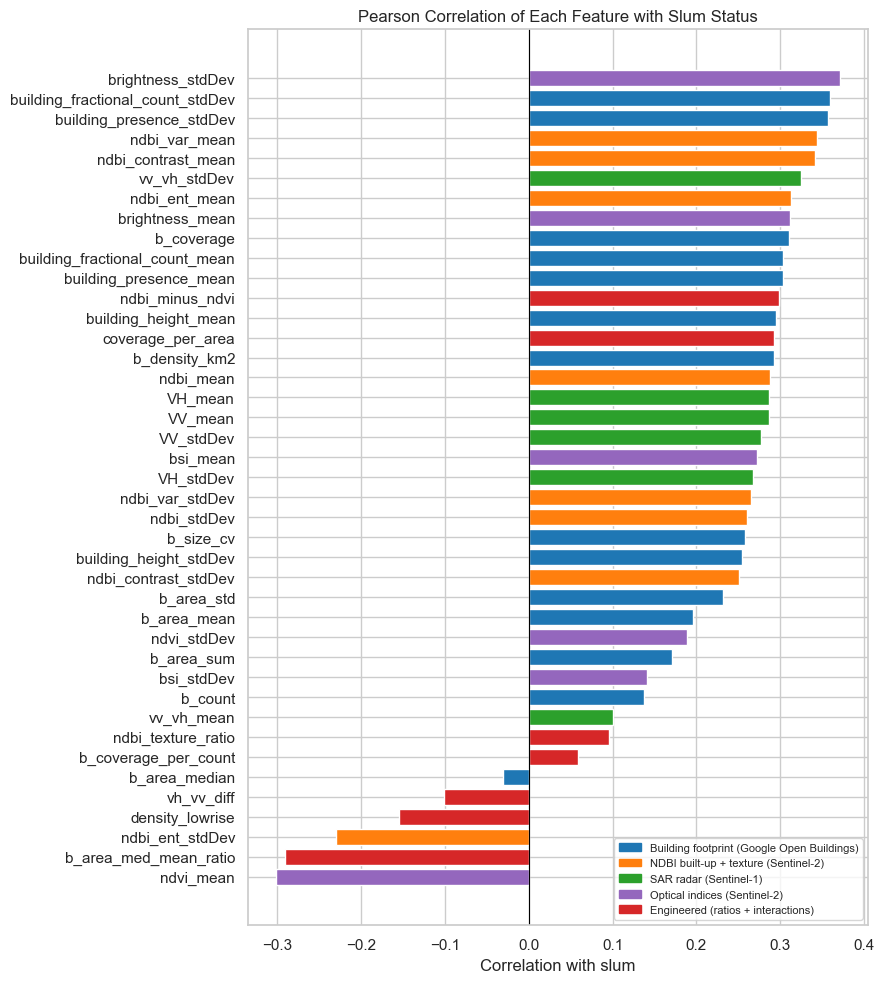

In [64]:
corr = df[FEATURES + ['slum']].corr()['slum'].drop('slum').sort_values()
colors_map = {
    'Building footprint (Google Open Buildings)': '#1f77b4',
    'NDBI built-up + texture (Sentinel-2)': '#ff7f0e',
    'SAR radar (Sentinel-1)': '#2ca02c',
    'Optical indices (Sentinel-2)': '#9467bd',
    'Engineered (ratios + interactions)': '#d62728',
}
bar_colors = [colors_map[feat_group[f]] for f in corr.index]

plt.figure(figsize=(9, 10))
plt.barh(corr.index, corr.values, color=bar_colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('Pearson Correlation of Each Feature with Slum Status')
plt.xlabel('Correlation with slum')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors_map.values()]
plt.legend(handles, colors_map.keys(), loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 Are features redundant with one another?
**Question:** How strongly are the features correlated among themselves? Highly correlated
clusters indicate redundancy, which tree ensembles handle well but which is useful to know
when interpreting importance.

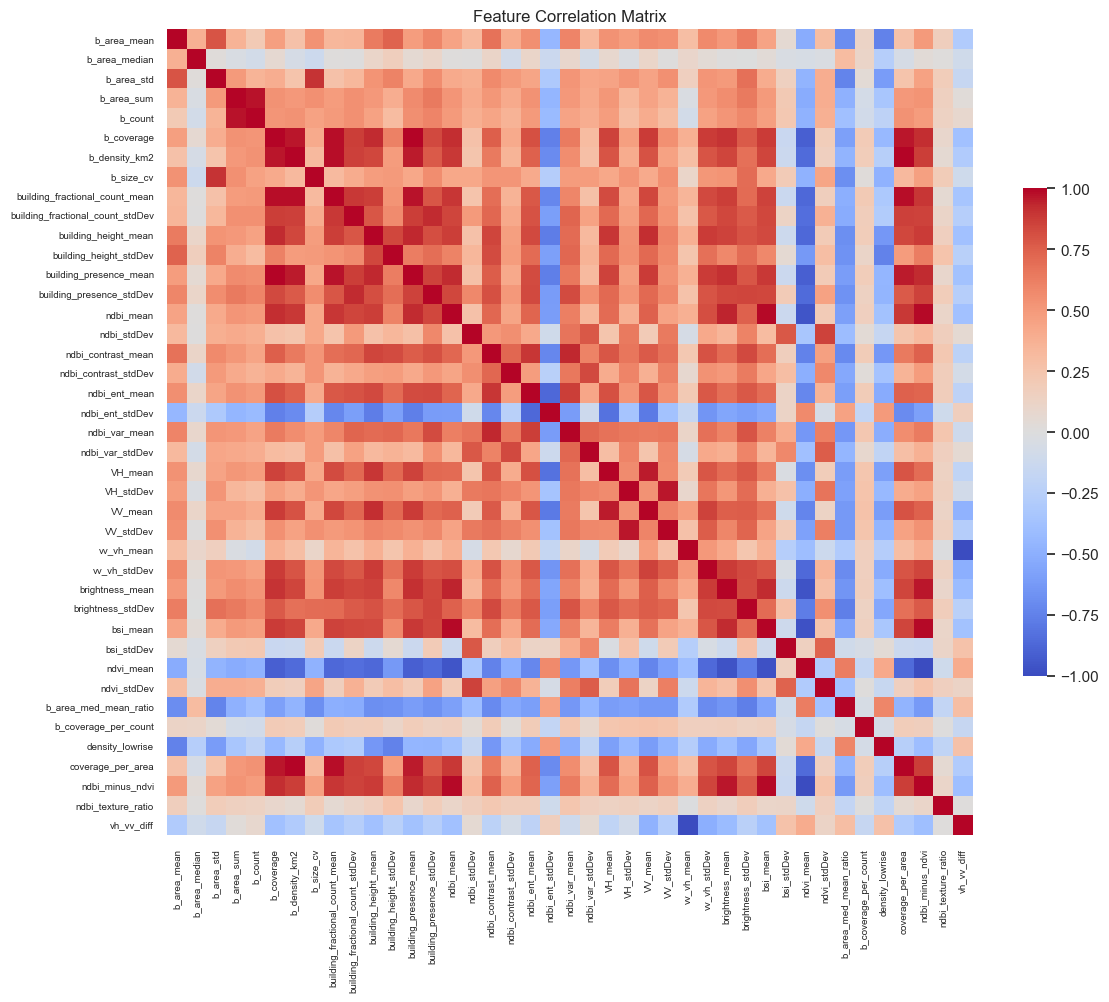

In [65]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[FEATURES].corr(), cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': 0.6}, xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Matrix')
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

### 3.4 Do slum and non-slum areas separate on the strongest features?
**Question:** For the six features most associated with the label, how do the class-conditional
distributions overlap? Clear separation suggests strong discriminative power.

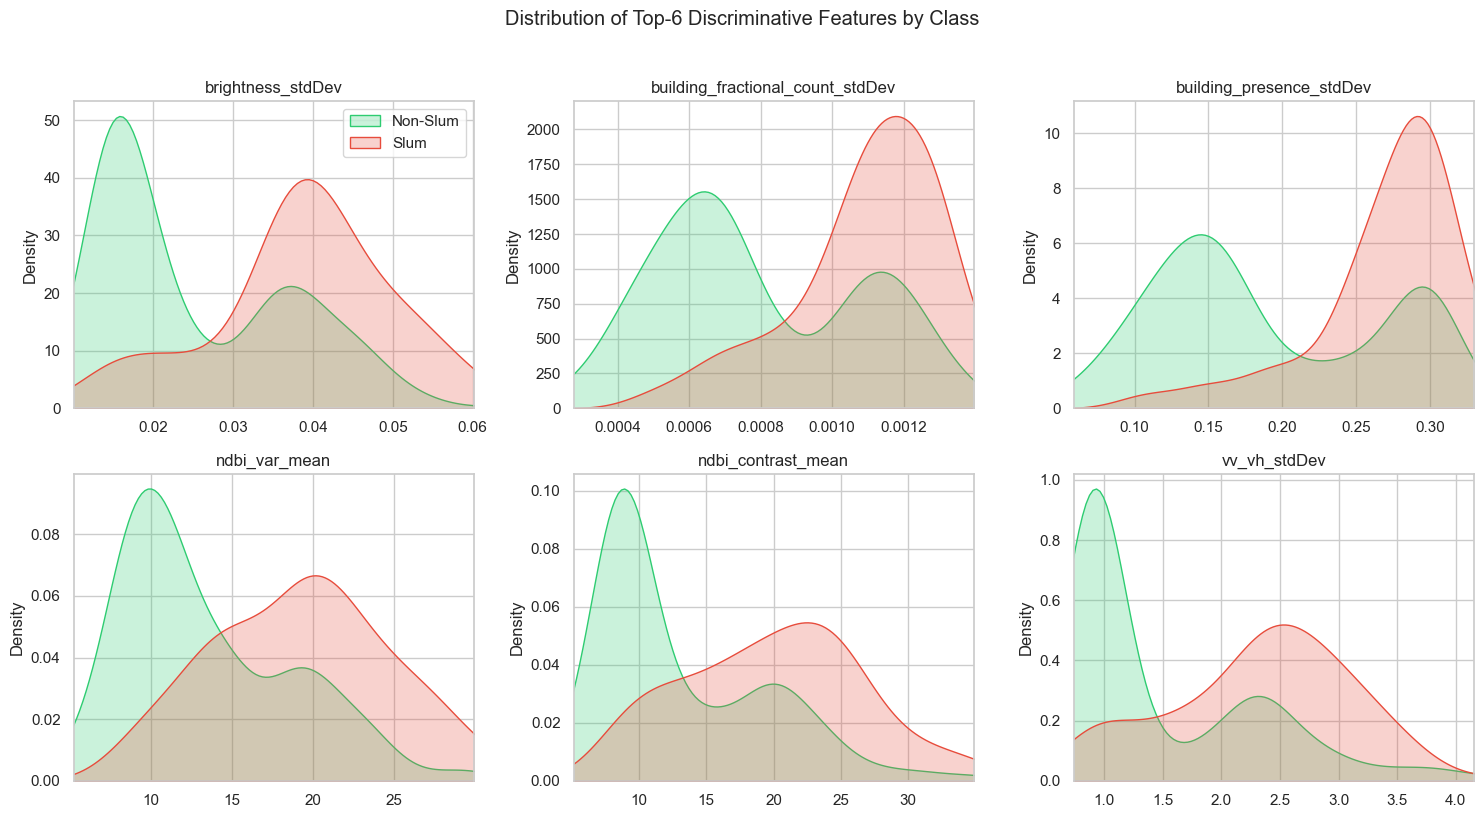

In [66]:
top_feats = corr.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axi, f in zip(axes.ravel(), top_feats):
    for cls in [0, 1]:
        sns.kdeplot(df.loc[df['slum'] == cls, f], ax=axi, fill=True,
                    color=PALETTE[cls], common_norm=False,
                    label=('Slum' if cls else 'Non-Slum'))
    axi.set_title(f)
    axi.set_xlabel('')
    axi.set_xlim(df[f].quantile(0.01), df[f].quantile(0.99))
axes.ravel()[0].legend()
fig.suptitle('Distribution of Top-6 Discriminative Features by Class', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Where do slums sit in spectral space?
**Question:** Plotting vegetation (NDVI) against built-up intensity (NDBI), do slum areas
occupy a distinct region — typically denser built-up and lower vegetation?

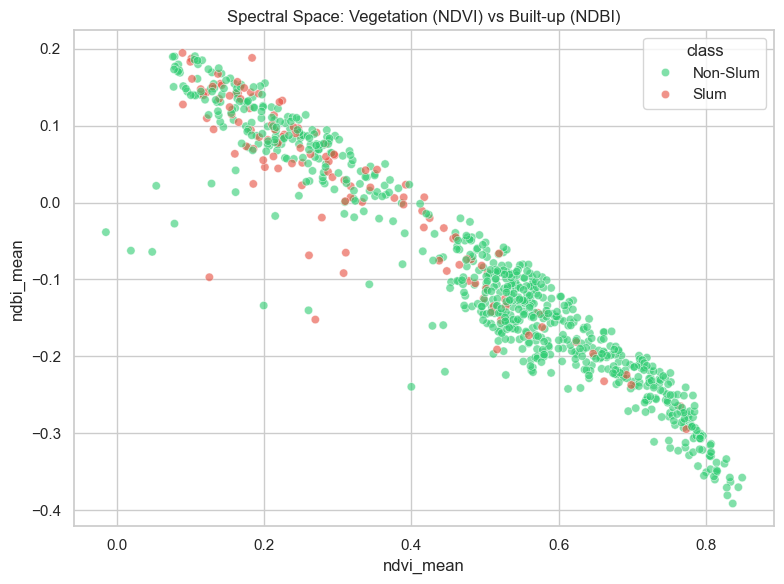

In [67]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='ndvi_mean', y='ndbi_mean', hue='slum', alpha=0.6, palette=PALETTE)
plt.title('Spectral Space: Vegetation (NDVI) vs Built-up (NDBI)')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Non-Slum', 'Slum'], title='class')
plt.tight_layout()
plt.show()

### 3.6 Do feature scales shift between cities?
**Question:** Do key features such as building density and built-up index have different
ranges across cities? Differences here are the reason we validate city-by-city rather than
with a random split.

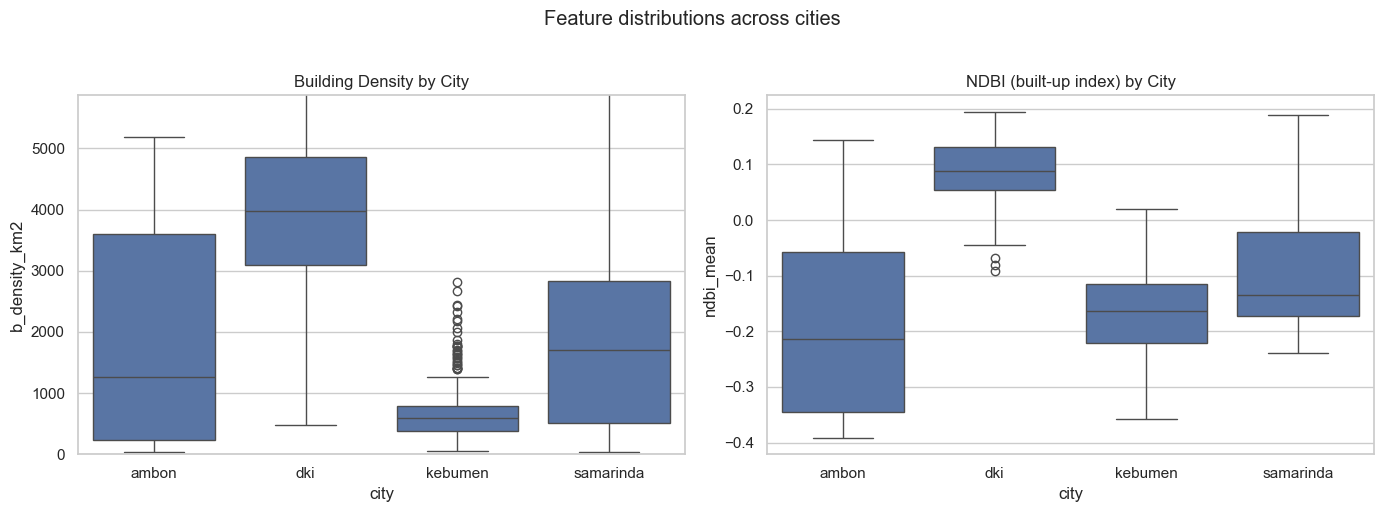

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='city', y='b_density_km2', ax=ax[0])
ax[0].set_ylim(0, df['b_density_km2'].quantile(0.97))
ax[0].set_title('Building Density by City')
sns.boxplot(data=df, x='city', y='ndbi_mean', ax=ax[1])
ax[1].set_title('NDBI (built-up index) by City')
fig.suptitle('Feature distributions across cities', y=1.02)
plt.tight_layout()
plt.show()

### 3.7 Geospatial overview
**Question:** Where are the slum kelurahan located, and how does building density vary across
space? Mapping the labels and a key feature gives a geographic feel for the problem before
modeling. Maps require the kelurahan boundary polygons; if the file is not found, these cells
are skipped automatically.

In [69]:
# Load kelurahan polygons and join them to the feature table for mapping.
gdf = None
try:
    import geopandas as gpd
    from pathlib import Path

    GEO_CANDIDATES = [
        '../data/processed/labels.geojson',
        '../data/processed/kelurahan.geojson',
        '../data/raw/labels.geojson',
        '../data/labels.geojson',
    ]
    geo_path = next((p for p in GEO_CANDIDATES if Path(p).exists()), None)
    if geo_path is None:
        print('Boundary polygons not found in expected locations; map cells will be skipped.')
        print('Set geo_path manually to your kelurahan boundary file to enable maps.')
    elif 'unit_id' not in df.columns:
        print('unit_id missing from feature table; cannot join polygons.')
    else:
        raw = gpd.read_file(geo_path)
        if 'unit_id' not in raw.columns:
            print(f'unit_id missing from {geo_path}; cannot join polygons.')
        else:
            gdf = raw[['unit_id', 'geometry']].merge(df, on='unit_id', how='inner')
            print(f'Loaded and joined {len(gdf)} polygons from {geo_path}.')
except ImportError:
    print('geopandas not installed; run `pip install geopandas contextily` to enable maps.')


def add_basemap(ax):
    # Optional CartoDB basemap; silently ignored if contextily/network is unavailable.
    try:
        import contextily as cx
        cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, attribution_size=5)
    except Exception:
        pass

Loaded and joined 828 polygons from ../data/processed/labels.geojson.


**Map 1 — Slum vs non-slum kelurahan.** Each city is shown in its own panel; red polygons are
slums, green are non-slums.

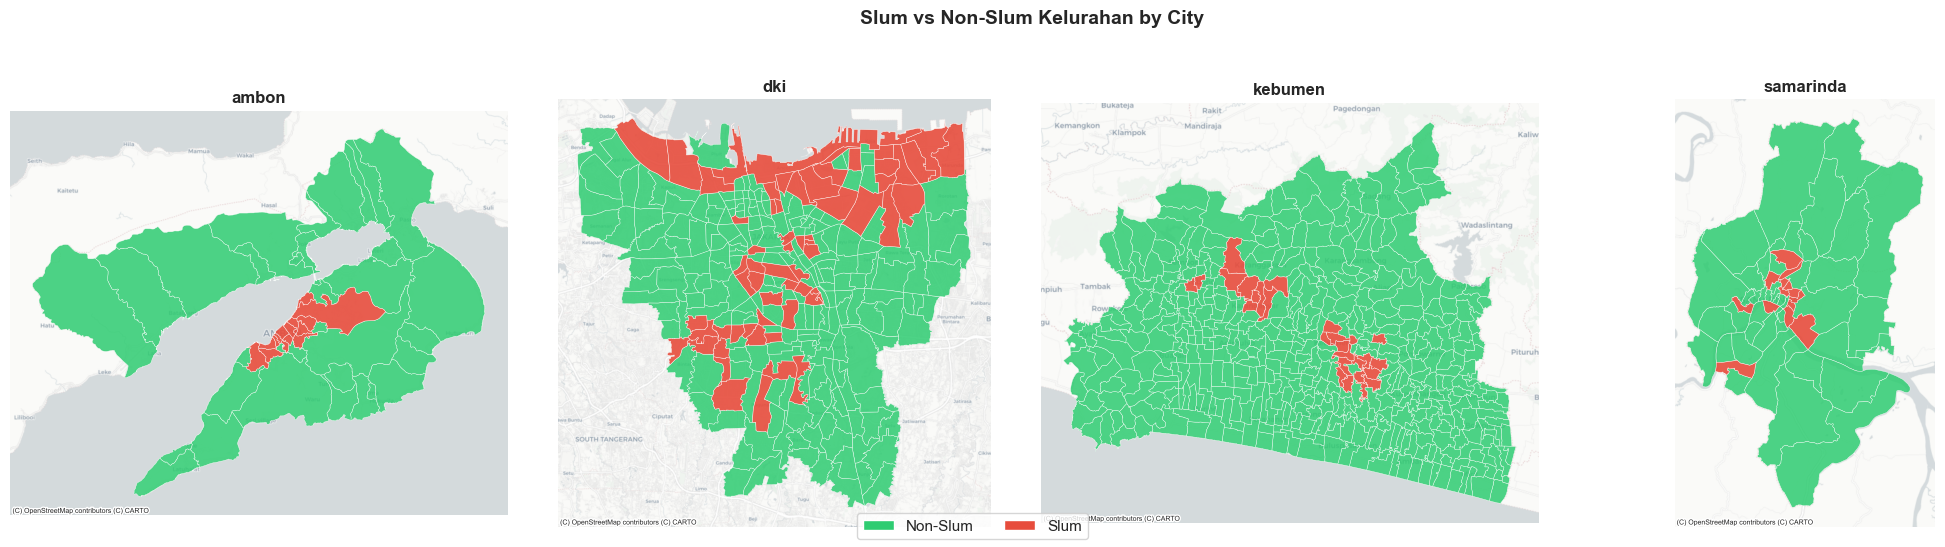

In [70]:
if gdf is not None:
    cities = sorted(gdf['city'].unique())
    fig, axes = plt.subplots(1, len(cities), figsize=(5.2 * len(cities), 5.2))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, cities):
        sub = gdf[gdf['city'] == c].to_crs(3857)
        sub[sub['slum'] == 0].plot(ax=ax, color=PALETTE[0], edgecolor='white',
                                   linewidth=0.3, alpha=0.85)
        sub[sub['slum'] == 1].plot(ax=ax, color=PALETTE[1], edgecolor='white',
                                   linewidth=0.3, alpha=0.9)
        add_basemap(ax)
        ax.set_title(c, fontweight='bold')
        ax.axis('off')
    legend_elems = [Patch(facecolor=PALETTE[0], label='Non-Slum'),
                    Patch(facecolor=PALETTE[1], label='Slum')]
    fig.legend(handles=legend_elems, loc='lower center', ncol=2, frameon=True)
    fig.suptitle('Slum vs Non-Slum Kelurahan by City', y=1.03, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Map skipped (no geometry available).')

**Map 2 — Building density.** A shared color scale (built-up density per km²) makes the
spatial pattern comparable across cities and against the slum map above.

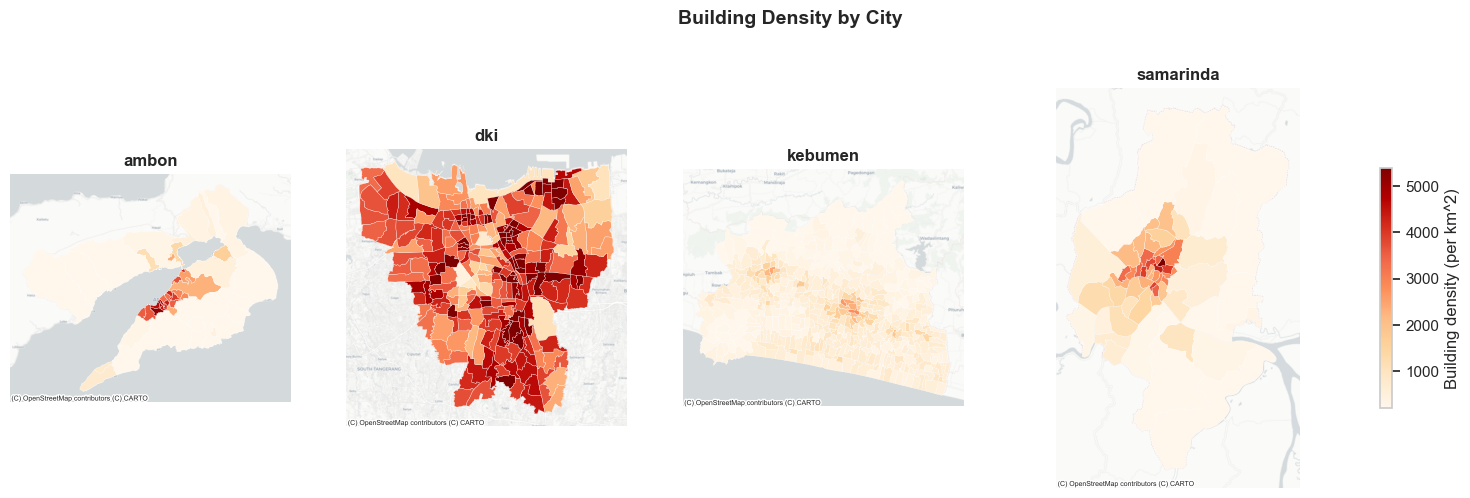

In [71]:
if gdf is not None:
    cities = sorted(gdf['city'].unique())
    vmin = float(gdf['b_density_km2'].quantile(0.05))
    vmax = float(gdf['b_density_km2'].quantile(0.95))
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = 'OrRd'

    fig, axes = plt.subplots(1, len(cities), figsize=(5.2 * len(cities), 5.2))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, cities):
        sub = gdf[gdf['city'] == c].to_crs(3857)
        sub.plot(column='b_density_km2', ax=ax, cmap=cmap, norm=norm,
                 edgecolor='white', linewidth=0.2)
        add_basemap(ax)
        ax.set_title(c, fontweight='bold')
        ax.axis('off')
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, shrink=0.6, label='Building density (per km^2)')
    fig.suptitle('Building Density by City', y=1.03, fontsize=14, fontweight='bold')
    plt.show()
else:
    print('Map skipped (no geometry available).')

## 4. Validation Strategy: Leave-One-City-Out (LOCO)

Kelurahan within the same city share environmental and morphological characteristics, and
feature scales shift between cities (Section 3.6). To measure performance on a genuinely
**new city**, we use Leave-One-City-Out cross-validation: the model trains on three cities
and is evaluated on the fourth, repeating until every city has served as the evaluation set
once. Class weights are computed from the training cities of each fold. The table below shows
the composition of each fold.

In [72]:
rows = []
for tr, te in LeaveOneGroupOut().split(np.zeros(len(y)), y, groups):
    rows.append({
        'eval_city': groups[te][0],
        'train_cities': ', '.join(sorted(np.unique(groups[tr]))),
        'n_train': len(tr), 'slum_train': int(y[tr].sum()),
        'n_eval': len(te), 'slum_eval': int(y[te].sum()),
    })
pd.DataFrame(rows)

,eval_city,train_cities,n_train,slum_train,n_eval,slum_eval
0,ambon,"dki, kebumen, samarinda",778,103,50,15
1,dki,"ambon, kebumen, samarinda",567,56,261,62
2,kebumen,"ambon, dki, samarinda",370,91,458,27
3,samarinda,"ambon, dki, kebumen",769,104,59,14


## 5. Model & Cross-City Prediction

The model is a compact pipeline: median imputation followed by an XGBoost classifier (trees
are scale-invariant, so no feature scaling is required). Parameters are deliberately
conservative to suit a small dataset. For each fold, `scale_pos_weight` is set from the
training cities to reflect their class balance, and the held-out city receives predictions
from a model that never saw it during training. Collecting these held-out predictions for all
four cities yields one prediction per kelurahan.

In [73]:
def make_xgb(scale_pos_weight, **params):
    cfg = dict(
        n_estimators=400, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, min_child_weight=2,
        scale_pos_weight=scale_pos_weight, objective='binary:logistic',
        eval_metric='aucpr', n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
    )
    cfg.update(params)
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(**cfg)),
    ])


def loco_oof(feature_cols, params=None):
    # Each city is predicted by a model trained on the other three cities.
    # scale_pos_weight is recomputed from the training cities of each fold.
    params = params or {}
    X = df[feature_cols]
    oof = np.zeros(len(y))
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
        model = make_xgb(spw, **params).fit(X.iloc[tr], y[tr])
        oof[te] = model.predict_proba(X.iloc[te])[:, 1]
    return oof


def per_city_metrics(oof):
    out = []
    for c in sorted(np.unique(groups)):
        m = groups == c
        out.append({
            'city': c, 'n': int(m.sum()), 'slum': int(y[m].sum()),
            'PR_AUC': average_precision_score(y[m], oof[m]),
            'ROC_AUC': roc_auc_score(y[m], oof[m]),
        })
    return pd.DataFrame(out)


oof = loco_oof(FEATURES)

## 6. Performance Metrics

Because the classes are imbalanced (~14% slums), **PR-AUC** (area under the precision-recall
curve) is the primary ranking metric, complemented by ROC-AUC. The lift over the prevalence
baseline shows how much better the model ranks slums than chance. A per-city breakdown
accompanies the pooled figure so performance can be read city by city.

In [74]:
pr_auc = average_precision_score(y, oof)
roc_auc = roc_auc_score(y, oof)
baseline = float(y.mean())

display(pd.DataFrame({
    'metric': ['PR-AUC (LOCO)', 'ROC-AUC (LOCO)',
               'Baseline PR-AUC (prevalence)', 'Lift over baseline (x)'],
    'value': [round(pr_auc, 4), round(roc_auc, 4),
              round(baseline, 4), round(pr_auc / baseline, 2)],
}))
per_city_metrics(oof).round(3)

,metric,value
0,PR-AUC (LOCO),0.2527
1,ROC-AUC (LOCO),0.7392
2,Baseline PR-AUC (prevalence),0.1425
3,Lift over baseline (x),1.7700


,city,n,slum,PR_AUC,ROC_AUC
0,ambon,50,15,0.639,0.830
1,dki,261,62,0.247,0.486
2,kebumen,458,27,0.445,0.783
3,samarinda,59,14,0.354,0.694


## 7. Classification Threshold & Detailed Report

To convert ranked probabilities into slum/non-slum decisions we choose an operating
threshold on the cross-validated predictions. Instead of simply maximizing F1 (which under
strong class imbalance tends to pick a very low threshold and floods the Non-Slum class with
false positives), we apply a **recall-constrained accuracy** rule: among all thresholds that
keep slum recall at or above a minimum operating level, we select the one that maximizes
overall accuracy. This guarantees the model still catches a required share of slums while
keeping its everyday predictions as correct as possible.

We then print the **full** classification report (precision, recall, F1, support for both
classes, plus overall accuracy), followed by the two primary headline metrics:

- **F1 (slum class)** — the harmonic mean of precision and recall on the minority class; the
  most informative single number when the classes are imbalanced.
- **Accuracy** — the overall share of correct predictions across all kelurahan.


In [75]:
prec, rec, thr = precision_recall_curve(y, oof)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best = int(np.nanargmax(f1_curve[:-1]))

# Threshold selection: among thresholds that keep slum recall >= MIN_RECALL,
# choose the one that maximizes overall accuracy. Falls back to the F1-optimal
# threshold if no threshold satisfies the recall constraint.
MIN_RECALL = 0.55
acc_curve = []
for t in thr:
    yp = (oof >= t).astype(int)
    if recall_score(y, yp, pos_label=1) >= MIN_RECALL:
        acc_curve.append((accuracy_score(y, yp), float(t)))
best_threshold = max(acc_curve)[1] if acc_curve else float(thr[best])
y_pred = (oof >= best_threshold).astype(int)

display(pd.Series({'operating_threshold': round(best_threshold, 3),
                   'min_recall_constraint': MIN_RECALL,
                   'recall_at_threshold': round(recall_score(y, y_pred, pos_label=1), 3),
                   'F1_at_threshold': round(f1_score(y, y_pred, pos_label=1), 3)}).to_frame('value'))

# Full classification report: precision / recall / f1 / support for each class + accuracy.
report_df = pd.DataFrame(classification_report(
    y, y_pred, target_names=['Non-Slum', 'Slum'], output_dict=True)).T.round(3)
display(report_df)

,value
operating_threshold,0.747
min_recall_constraint,0.550
recall_at_threshold,0.551
F1_at_threshold,0.346


,precision,recall,f1-score,support
Non-Slum,0.907,0.728,0.808,710.000
Slum,0.252,0.551,0.346,118.000
accuracy,0.703,0.703,0.703,0.703
macro avg,0.579,0.640,0.577,828.000
weighted avg,0.814,0.703,0.742,828.000


## 7.5 Threshold strategy comparison — which cut-off should we ship?

The default rule in Section 7 (keep recall ≥ 0.55, then **maximize accuracy**) pushes the
threshold high (~0.75). On an **imbalanced** problem (slum prevalence ≈ 14%) maximizing
accuracy rewards predicting the majority *non-slum* class, so genuinely slum areas that score
e.g. 0.65 fall below the cut-off and are missed (false negatives).

Below we compare several **documented, citable** ways to set the operating threshold. All are
evaluated on the *same* honest **Leave-One-City-Out out-of-fold scores** (`oof`), so the table
reflects generalization to unseen cities, not training fit.

| Strategy | Rule | Reference |
|---|---|---|
| F1-optimal | maximize F1 on the PR curve | van Rijsbergen (1979) |
| **F2-optimal** | maximize Fβ with β=2 — weights **recall 2×** precision | He & Garcia (2009), *IEEE TKDE* |
| Youden's J | maximize `sensitivity + specificity − 1` on ROC | Youden (1950), *Cancer* 3(1) |
| Target-recall | highest threshold keeping recall ≥ 0.80, report precision | Saito & Rehmsmeier (2015), *PLoS ONE* |
| Isotonic-calibrated | calibrate probabilities, cut at 0.5 (mapped back to a raw threshold) | Niculescu-Mizil & Caruana (2005), ICML |

**Domain rationale for favouring recall:** in slum mapping a *false negative* (missing a
settlement that needs intervention) is costlier than a *false positive*; the remote-sensing
slum-mapping literature explicitly prioritizes recall / producer's accuracy — Kuffer, Pfeffer
& Sliuzas (2016), *“Slums from Space”, Remote Sensing* 8(6):455.


In [76]:
# ---- Compare threshold strategies on the honest LOCO out-of-fold scores (`oof`) ----
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import fbeta_score, matthews_corrcoef

def eval_threshold(t):
    """Full slum-class metrics for a given probability cut-off, on (y, oof)."""
    yp = (oof >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        'threshold':   round(float(t), 4),
        'precision':   round(precision_score(y, yp, pos_label=1, zero_division=0), 3),
        'recall':      round(recall_score(y, yp, pos_label=1, zero_division=0), 3),
        'specificity': round(float(specificity), 3),
        'F1':          round(f1_score(y, yp, pos_label=1, zero_division=0), 3),
        'F2':          round(fbeta_score(y, yp, beta=2, pos_label=1, zero_division=0), 3),
        'accuracy':    round(accuracy_score(y, yp), 3),
        'MCC':         round(matthews_corrcoef(y, yp), 3),
        'n_pred_slum': int(yp.sum()),
    }

# Precision-Recall curve drives F1 / F2 / target-recall; ROC drives Youden's J.
prec, rec, thr = precision_recall_curve(y, oof)          # len(thr) == len(prec) - 1
f1c = 2 * prec * rec / (prec + rec + 1e-12)
f2c = 5 * prec * rec / (4 * prec + rec + 1e-12)          # F-beta, beta=2
thr_f1 = float(thr[np.nanargmax(f1c[:-1])])
thr_f2 = float(thr[np.nanargmax(f2c[:-1])])

fpr, tpr, roc_thr = roc_curve(y, oof)
thr_j = float(roc_thr[np.argmax(tpr - fpr)])             # Youden's J

# Target recall: the HIGHEST threshold that still keeps slum recall >= target
# (highest threshold -> best precision among those that satisfy the recall floor).
TARGET_RECALL = 0.80
ok = [float(t) for t in thr
      if recall_score(y, (oof >= t).astype(int), pos_label=1, zero_division=0) >= TARGET_RECALL]
thr_tr = max(ok) if ok else thr_f2

# Current shipped rule (Section 7): recall >= 0.55, then maximize accuracy.
MIN_RECALL = 0.55
acc_cand = [(accuracy_score(y, (oof >= t).astype(int)), float(t)) for t in thr
            if recall_score(y, (oof >= t).astype(int), pos_label=1, zero_division=0) >= MIN_RECALL]
thr_curr = max(acc_cand)[1] if acc_cand else thr_f1

# Isotonic calibration: make probabilities meaningful, cut at 0.5, then map that
# back to an equivalent RAW-probability threshold so the API still uses ONE number
# on the model's raw output (no calibrator needed at serving time).
iso = IsotonicRegression(out_of_bounds='clip').fit(oof, y)
p_cal = iso.transform(oof)
raw_at_half = oof[p_cal >= 0.5]
thr_cal = float(raw_at_half.min()) if raw_at_half.size else thr_f1

strategies = {
    'Current (recall>=0.55, max accuracy)': thr_curr,
    'F1-optimal':                           thr_f1,
    'F2-optimal (recall-weighted)':         thr_f2,
    "Youden's J (ROC)":                      thr_j,
    f'Target recall >= {TARGET_RECALL:.2f}': thr_tr,
    'Isotonic-calibrated @ 0.5':            thr_cal,
}

comparison = (pd.DataFrame([{'strategy': k, **eval_threshold(v)} for k, v in strategies.items()])
              .set_index('strategy'))
print('Threshold strategies compared on LOCO out-of-fold predictions '
      f'(n={len(y)}, slum prevalence={y.mean():.3f}):')
display(comparison)


Threshold strategies compared on LOCO out-of-fold predictions (n=828, slum prevalence=0.143):


,threshold,precision,recall,specificity,F1,F2,accuracy,MCC,n_pred_slum
strategy,,,,,,,,,
"Current (recall>=0.55, max accuracy)",0.7467,0.252,0.551,0.728,0.346,0.445,0.703,0.211,258
F1-optimal,0.0692,0.287,0.831,0.656,0.426,0.602,0.681,0.346,342
F2-optimal (recall-weighted),0.0175,0.269,0.915,0.587,0.416,0.619,0.634,0.352,401
Youden's J (ROC),0.0222,0.275,0.898,0.607,0.421,0.618,0.649,0.354,385
Target recall >= 0.80,0.1013,0.285,0.805,0.665,0.421,0.590,0.685,0.335,333
Isotonic-calibrated @ 0.5,0.0692,0.287,0.831,0.656,0.426,0.602,0.681,0.346,342


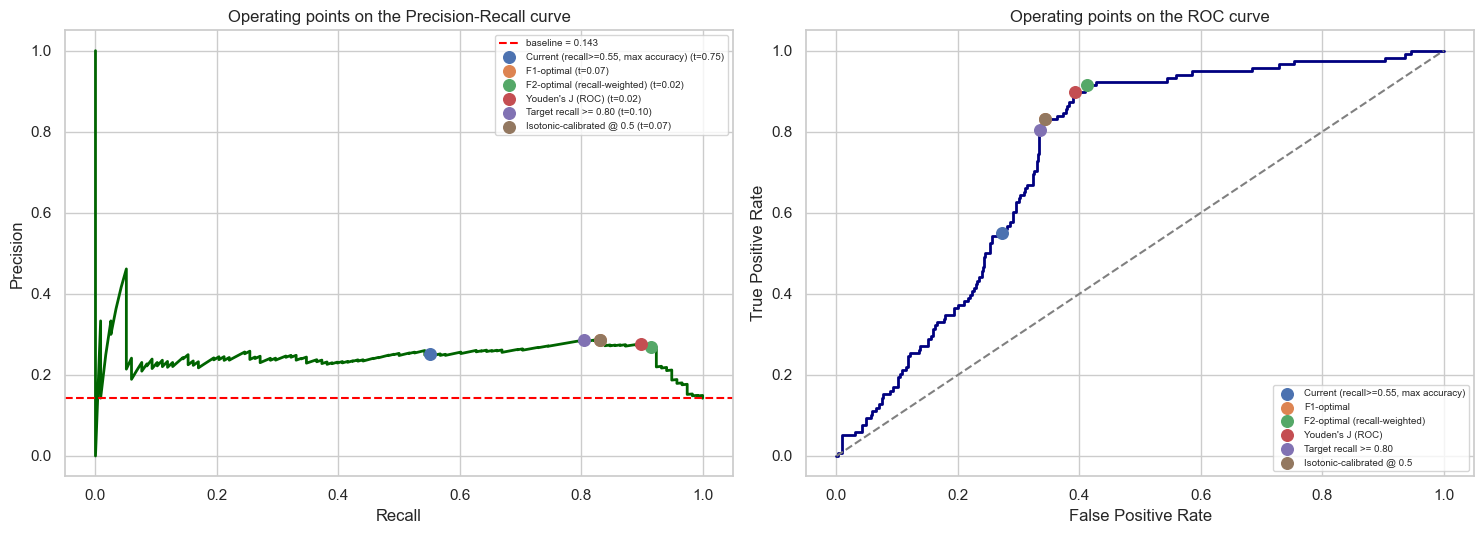

In [77]:
# ---- Visualize every candidate operating point on the PR and ROC curves ----
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))

ax[0].plot(rec, prec, color='darkgreen', lw=2, zorder=1)
ax[0].axhline(baseline, ls='--', color='red', label=f'baseline = {baseline:.3f}')
for name, t in strategies.items():
    yp = (oof >= t).astype(int)
    r = recall_score(y, yp, pos_label=1, zero_division=0)
    p = precision_score(y, yp, pos_label=1, zero_division=0)
    ax[0].scatter([r], [p], s=70, zorder=5, label=f'{name} (t={t:.2f})')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Operating points on the Precision-Recall curve')
ax[0].legend(fontsize=7, loc='upper right')

ax[1].plot(fpr, tpr, color='navy', lw=2, zorder=1)
ax[1].plot([0, 1], [0, 1], ls='--', color='grey')
for name, t in strategies.items():
    yp = (oof >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yp, labels=[0, 1]).ravel()
    ax[1].scatter([fp / (fp + tn + 1e-12)], [tp / (tp + fn + 1e-12)], s=70, zorder=5, label=name)
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title("Operating points on the ROC curve")
ax[1].legend(fontsize=7, loc='lower right')

plt.tight_layout(); plt.show()


### Pick the threshold to ship

Read the table and plot above, then set `SELECTED_STRATEGY` to the row that best balances
**catching real slums (recall)** against **false alarms (precision)** for your use case.
The choice flows into every downstream cell (report, confusion matrix, inference) and into the
exported `model_metadata.json`, so the API picks it up automatically on its next load.

Default = **F2-optimal**: it explicitly weights recall 2×, directly addressing the
“known slum areas scored below the cut-off” problem, and is defensible via the imbalanced-learning
and slum-mapping references above. (You can still override it live in the API via the
`SLUM_THRESHOLD` env var without re-running this notebook.)


In [78]:
# Change from F2-optimal to isotonic-calibrated @ 0.5 after comparing the strategies in the table and curves above.
SELECTED_STRATEGY = 'Target recall >= 0.80'

best_threshold = float(strategies[SELECTED_STRATEGY])   # used by all downstream cells + export
y_pred = (oof >= best_threshold).astype(int)
print(f'Selected strategy : {SELECTED_STRATEGY}')
print(f'operating_threshold = {best_threshold:.4f}')
display(pd.DataFrame([{'strategy': SELECTED_STRATEGY, **eval_threshold(best_threshold)}])
        .set_index('strategy'))

Selected strategy : Target recall >= 0.80
operating_threshold = 0.1013


,threshold,precision,recall,specificity,F1,F2,accuracy,MCC,n_pred_slum
strategy,,,,,,,,,
Target recall >= 0.80,0.1013,0.285,0.805,0.665,0.421,0.59,0.685,0.335,333


In [79]:
# All evaluation metrics in one table.
acc = accuracy_score(y, y_pred)
prec_slum = precision_score(y, y_pred, pos_label=1)
rec_slum = recall_score(y, y_pred, pos_label=1)
f1_slum = f1_score(y, y_pred, pos_label=1)
f1_macro = f1_score(y, y_pred, average='macro')

all_metrics = pd.DataFrame({
    'metric': ['Accuracy', 'Precision (Slum)', 'Recall (Slum)', 'F1 (Slum)',
               'F1 (macro)', 'PR-AUC', 'ROC-AUC'],
    'value': [round(acc, 4), round(prec_slum, 4), round(rec_slum, 4),
              round(f1_slum, 4), round(f1_macro, 4), round(pr_auc, 4), round(roc_auc, 4)],
})
display(all_metrics)

# Primary headline metrics for this imbalanced task.
print('Primary metrics')
print(f'  F1 (Slum)  : {f1_slum:.3f}  -> balances precision and recall on the minority class')
print(f'  Accuracy   : {acc:.3f}  -> overall share of correct predictions')

,metric,value
0,Accuracy,0.6848
1,Precision (Slum),0.2853
2,Recall (Slum),0.8051
3,F1 (Slum),0.4213
4,F1 (macro),0.6023
5,PR-AUC,0.2527
6,ROC-AUC,0.7392


Primary metrics
  F1 (Slum)  : 0.421  -> balances precision and recall on the minority class
  Accuracy   : 0.685  -> overall share of correct predictions


## 8. Evaluation Plots

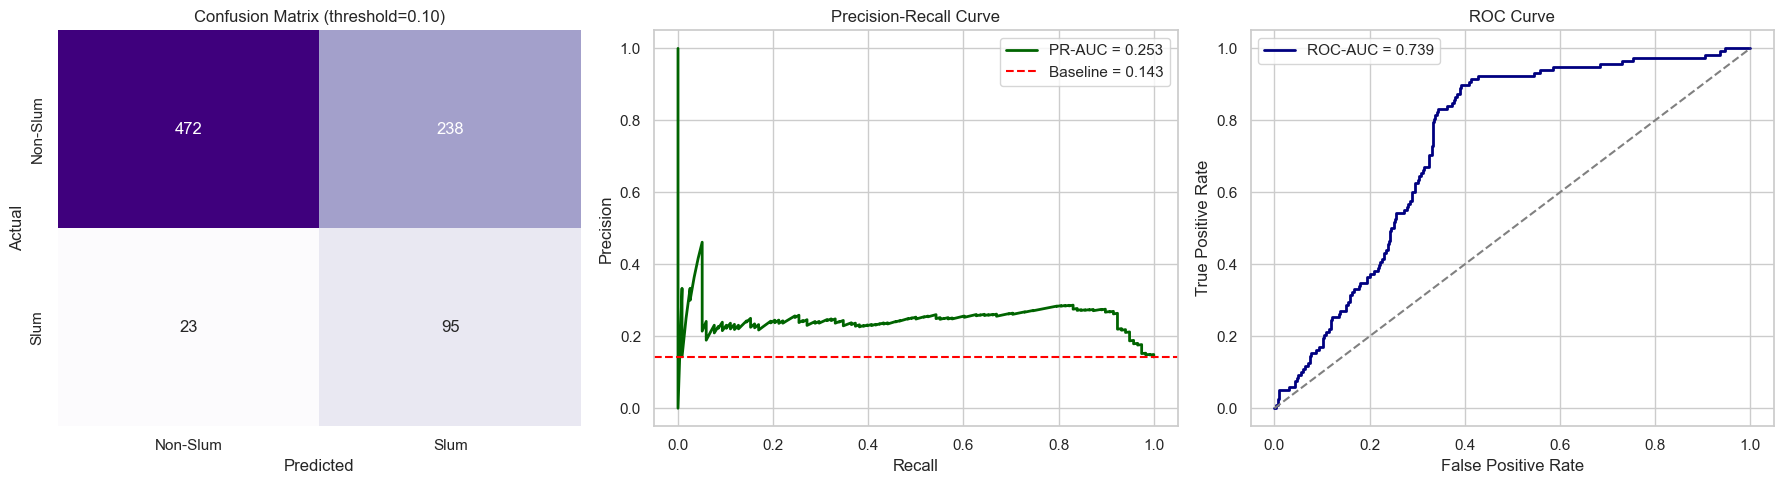

In [80]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Non-Slum', 'Slum'], yticklabels=['Non-Slum', 'Slum'], ax=ax[0])
ax[0].set_title(f'Confusion Matrix (threshold={best_threshold:.2f})')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')

ax[1].plot(rec, prec, color='darkgreen', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax[1].axhline(baseline, ls='--', color='red', label=f'Baseline = {baseline:.3f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve'); ax[1].legend()

fpr, tpr, _ = roc_curve(y, oof)
ax[2].plot(fpr, tpr, color='navy', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax[2].plot([0, 1], [0, 1], ls='--', color='grey')
ax[2].set_xlabel('False Positive Rate'); ax[2].set_ylabel('True Positive Rate')
ax[2].set_title('ROC Curve'); ax[2].legend()

plt.tight_layout()
plt.show()

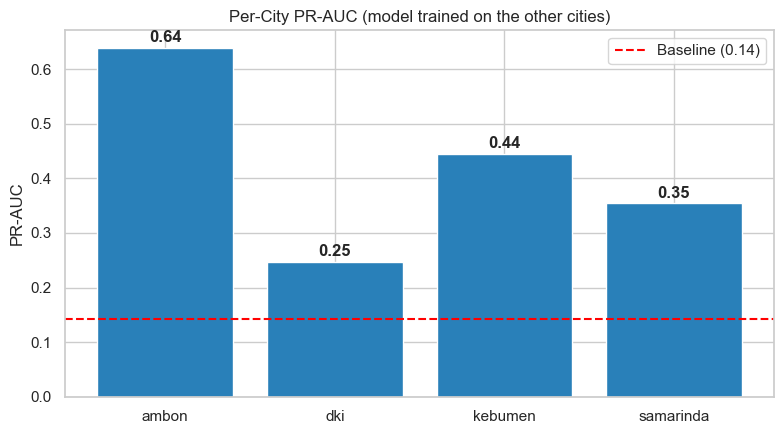

In [81]:
pc = per_city_metrics(oof)
plt.figure(figsize=(8, 4.5))
plt.bar(pc['city'], pc['PR_AUC'], color='#2980b9')
plt.axhline(baseline, ls='--', color='red', label=f'Baseline ({baseline:.2f})')
for i, v in enumerate(pc['PR_AUC']):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')
plt.title('Per-City PR-AUC (model trained on the other cities)')
plt.ylabel('PR-AUC'); plt.legend()
plt.tight_layout()
plt.show()

**Map 3 — Predicted slum risk.** The cross-validated slum probability for each kelurahan,
mapped per city. Brighter areas are higher predicted risk and can be compared directly with
the ground-truth slum map in Section 3.7.

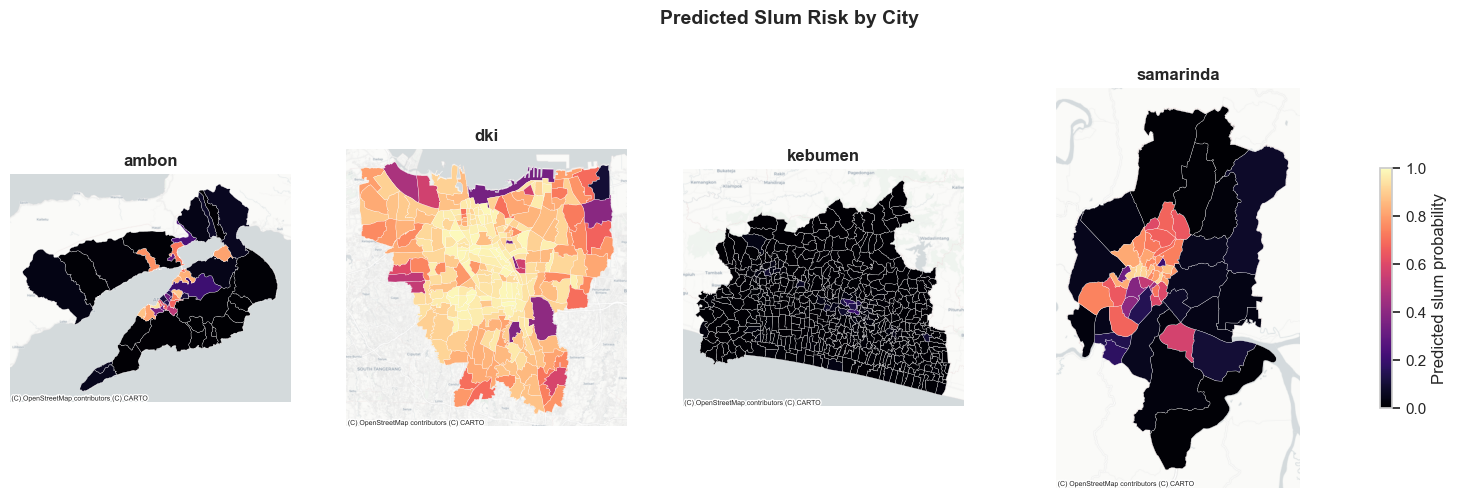

In [82]:
if gdf is not None:
    prob_by_id = pd.Series(oof, index=df['unit_id'])
    gpred = gdf.copy()
    gpred['slum_probability'] = gpred['unit_id'].map(prob_by_id)

    cities = sorted(gpred['city'].unique())
    norm = Normalize(vmin=0.0, vmax=1.0)
    cmap = 'magma'
    fig, axes = plt.subplots(1, len(cities), figsize=(5.2 * len(cities), 5.2))
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, cities):
        sub = gpred[gpred['city'] == c].to_crs(3857)
        sub.plot(column='slum_probability', ax=ax, cmap=cmap, norm=norm,
                 edgecolor='white', linewidth=0.2)
        add_basemap(ax)
        ax.set_title(c, fontweight='bold')
        ax.axis('off')
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=axes, shrink=0.6, label='Predicted slum probability')
    fig.suptitle('Predicted Slum Risk by City', y=1.03, fontsize=14, fontweight='bold')
    plt.show()
else:
    print('Map skipped (no geometry available).')

## 9. Feature Importance (SHAP)

For interpretation, a model is fit on all kelurahan and explained with SHAP values, which
attribute each prediction to its features. The summary plot ranks features by overall impact
and shows the direction of their effect across all data sources.

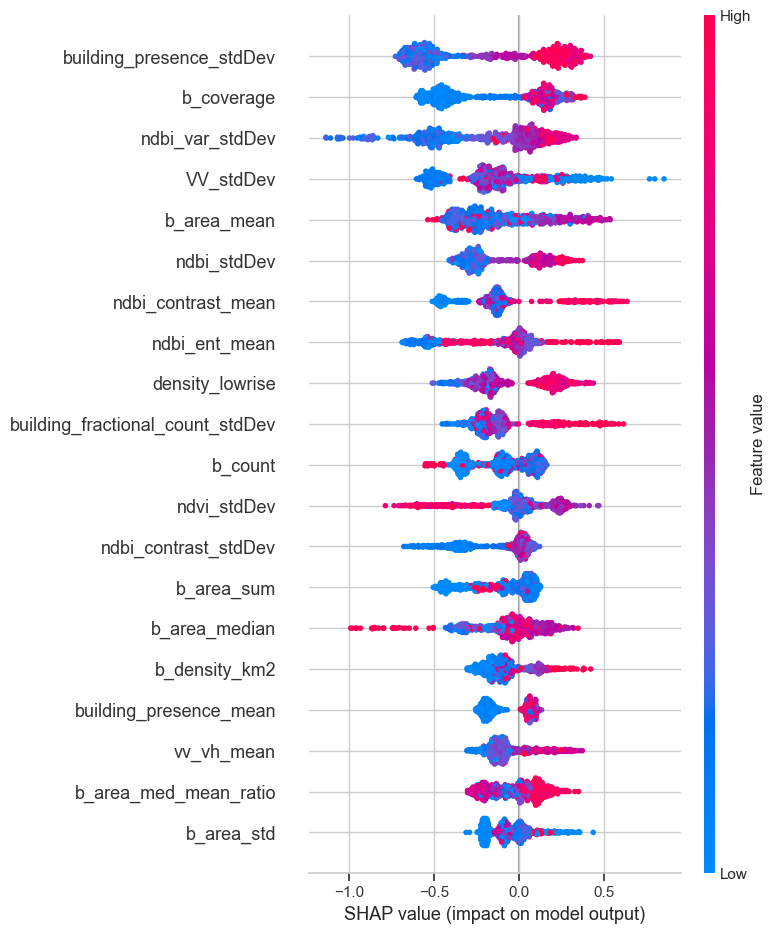

In [83]:
spw_all = (y == 0).sum() / (y == 1).sum()
final_model = make_xgb(spw_all).fit(df[FEATURES], y)

clf = final_model.named_steps['clf']
X_imputed = pd.DataFrame(final_model.named_steps['imputer'].transform(df[FEATURES]),
                         columns=FEATURES)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_imputed)
shap.summary_plot(shap_values, X_imputed, max_display=20)

## 10. Data Source Contribution

How much do the spectral (Sentinel-2) and radar (Sentinel-1) sources add on top of the
building-footprint features alone? Both feature sets are evaluated under the identical LOCO
protocol so the comparison is on equal footing.

In [84]:
oof_building = loco_oof(CORE_BUILDING)
ablation = pd.DataFrame([
    {'feature_set': 'Building footprint only', 'n_features': len(CORE_BUILDING),
     'PR_AUC': average_precision_score(y, oof_building),
     'ROC_AUC': roc_auc_score(y, oof_building)},
    {'feature_set': 'All features (fusion)', 'n_features': len(FEATURES),
     'PR_AUC': pr_auc, 'ROC_AUC': roc_auc},
]).round(4)
ablation['PR_AUC_gain'] = (ablation['PR_AUC'] - ablation['PR_AUC'].iloc[0]).round(4)
ablation

,feature_set,n_features,PR_AUC,ROC_AUC,PR_AUC_gain
0,Building footprint only,14,0.2555,0.7441,0.0000
1,All features (fusion),41,0.2527,0.7392,-0.0028


## 11. Hyperparameter Tuning Comparison

This section compares the fixed, pre-registered hyperparameters against a nested randomized
search that tunes the model **inside** each training split and evaluates on the held-out city.
On a dataset of this size, well-chosen fixed parameters are often competitive with tuning.
Run this cell only when you want the comparison, as it is slower.

In [85]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__n_estimators': [300, 400],
    'clf__max_depth': [2, 3, 4],
    'clf__learning_rate': [0.01, 0.03, 0.05],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__min_child_weight': [2, 4],
} 


def nested_loco_oof(feature_cols):
    X = df[feature_cols]
    oof_t = np.zeros(len(y))
    fold_best = []
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        eval_city = groups[te][0]
        spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
        search = GridSearchCV(
            make_xgb(spw, n_jobs=1), param_grid, scoring='average_precision',
            cv=GroupKFold(n_splits=3), n_jobs=-1,
        )
        search.fit(X.iloc[tr], y[tr], groups=groups[tr])
        oof_t[te] = search.best_estimator_.predict_proba(X.iloc[te])[:, 1]
        bp = {k.replace('clf__', ''): v for k, v in search.best_params_.items()}
        bp['eval_city'] = eval_city
        bp['inner_PR_AUC'] = round(float(search.best_score_), 4)
        fold_best.append(bp)
    return oof_t, pd.DataFrame(fold_best)


oof_tuned, best_params_per_fold = nested_loco_oof(FEATURES)

param_cols = ['eval_city', 'n_estimators', 'max_depth', 'learning_rate',
              'subsample', 'colsample_bytree', 'min_child_weight', 'inner_PR_AUC']
print('Best parameters per held-out city')
display(best_params_per_fold[[c for c in param_cols if c in best_params_per_fold.columns]])

pr_auc_tuned = average_precision_score(y, oof_tuned)
roc_auc_tuned = roc_auc_score(y, oof_tuned)
display(pd.DataFrame({
    'approach': ['Fixed params (Section 5)', 'Nested-CV tuned'],
    'PR_AUC': [round(pr_auc, 4), round(pr_auc_tuned, 4)],
    'ROC_AUC': [round(roc_auc, 4), round(roc_auc_tuned, 4)],
}))

prec_t, rec_t, thr_t = precision_recall_curve(y, oof_tuned)
f1_curve_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-12)
best_t = int(np.nanargmax(f1_curve_t[:-1]))
threshold_tuned = float(thr_t[best_t])
y_pred_tuned = (oof_tuned >= threshold_tuned).astype(int)

display(pd.Series({'operating_threshold': round(threshold_tuned, 3),
                   'max_F1': round(float(f1_curve_t[best_t]), 3)}).to_frame('value'))

report_tuned = pd.DataFrame(classification_report(
    y, y_pred_tuned, target_names=['Non-Slum', 'Slum'], output_dict=True)).T.round(3)
display(report_tuned)

acc_t = accuracy_score(y, y_pred_tuned)
all_metrics_tuned = pd.DataFrame({
    'metric': ['Accuracy', 'Precision (Slum)', 'Recall (Slum)', 'F1 (Slum)',
               'F1 (macro)', 'PR-AUC', 'ROC-AUC'],
    'value': [round(acc_t, 4),
              round(precision_score(y, y_pred_tuned, pos_label=1), 4),
              round(recall_score(y, y_pred_tuned, pos_label=1), 4),
              round(f1_score(y, y_pred_tuned, pos_label=1), 4),
              round(f1_score(y, y_pred_tuned, average='macro'), 4),
              round(pr_auc_tuned, 4), round(roc_auc_tuned, 4)],
})
display(all_metrics_tuned)

print('Primary metrics (tuned model)')
print(f'  F1 (Slum)  : {f1_score(y, y_pred_tuned, pos_label=1):.3f}')
print(f'  Accuracy   : {acc_t:.3f}')

Best parameters per held-out city


,eval_city,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,inner_PR_AUC
0,ambon,400,2,0.03,1.0,0.8,4,0.3473
1,dki,300,2,0.01,0.8,0.8,4,0.5587
2,kebumen,400,2,0.01,1.0,0.8,2,0.5239
3,samarinda,400,2,0.01,0.8,1.0,2,0.4593


,approach,PR_AUC,ROC_AUC
0,Fixed params (Section 5),0.2527,0.7392
1,Nested-CV tuned,0.2787,0.7466


,value
operating_threshold,0.185
max_F1,0.433


,precision,recall,f1-score,support
Non-Slum,0.976,0.621,0.759,710.000
Slum,0.285,0.907,0.433,118.000
accuracy,0.662,0.662,0.662,0.662
macro avg,0.630,0.764,0.596,828.000
weighted avg,0.877,0.662,0.713,828.000


,metric,value
0,Accuracy,0.6618
1,Precision (Slum),0.2846
2,Recall (Slum),0.9068
3,F1 (Slum),0.4332
4,F1 (macro),0.5961
5,PR-AUC,0.2787
6,ROC-AUC,0.7466


Primary metrics (tuned model)
  F1 (Slum)  : 0.433
  Accuracy   : 0.662


## 12. Inference on New Areas

`predict_new_area` scores any dataframe that shares the feature columns and returns the slum
probability and the thresholded prediction. To estimate performance on a new region, apply it
to data from a city outside the training set. The demo below scores a few sample rows to show
the output format.

In [86]:
def predict_new_area(df_new, model=final_model, features=FEATURES, threshold=best_threshold):
    proba = model.predict_proba(df_new[features])[:, 1]
    out = df_new.copy()
    out['slum_probability'] = proba
    out['slum_prediction'] = (proba >= threshold).astype(int)
    return out


demo = predict_new_area(df.sample(5, random_state=10))
demo[['unit_id', 'city', 'slum', 'slum_probability', 'slum_prediction']]

,unit_id,city,slum,slum_probability,slum_prediction
339,kebumen_0028,kebumen,0,0.027263,0
68,dki_0018,dki,0,0.294973,1
264,dki_0214,dki,0,0.279478,1
278,dki_0228,dki,0,0.242480,1
529,kebumen_0218,kebumen,1,0.913140,1


## 13. Export for Deployment + Local Explanations (XAI)

Persist the deployment pipeline (median imputer + XGBoost, already fit on all four cities)
together with the metadata a FastAPI service needs: the exact feature order, the raw columns
the API must receive, the formulas to rebuild the 7 engineered features, the operating
threshold, and the SHAP explainer. `local_explanation` returns the per-prediction (local)
SHAP contributions — this is the structured evidence to feed an LLM for natural-language
explanations.

In [87]:
import joblib, json, os
from datetime import date

EXPORT_DIR = '../models'
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) Deployment pipeline (imputer + XGBoost), already fit on ALL cities in Section 9.
joblib.dump(final_model, f'{EXPORT_DIR}/slum_xgb_pipeline.joblib')

# 2) Reusable SHAP explainer for per-prediction (local) explanations.
joblib.dump(explainer, f'{EXPORT_DIR}/shap_explainer.joblib')

# 3) Raw columns the API must receive (engineered features are DERIVED from these).
RAW_FEATURES = [c for c in (CORE_BUILDING + NDBI_BUILTUP + SAR_SENTINEL1 + OPTICAL_INDICES)
                if c in df.columns]

# 4) Formulas so the API reproduces Section 2.5 exactly (eps = 1e-6).
ENGINEERED_FORMULAS = {
    'b_area_med_mean_ratio': 'b_area_median / (b_area_mean + 1e-6)',
    'b_coverage_per_count':  'b_coverage / (b_count + 1e-6)',
    'density_lowrise':       'b_density_km2 / (building_height_mean + 1e-6)',
    'coverage_per_area':     'b_coverage / (b_area_mean + 1e-6)',
    'ndbi_minus_ndvi':       'ndbi_mean - ndvi_mean',
    'ndbi_texture_ratio':    'ndbi_contrast_mean / (abs(ndbi_mean) + 1e-6)',
    'vh_vv_diff':            'VH_mean - VV_mean',
}

metadata = {
    'model_file': 'slum_xgb_pipeline.joblib',
    'explainer_file': 'shap_explainer.joblib',
    'created': str(date.today()),
    'target': {'0': 'Non-Slum', '1': 'Slum'},
    'operating_threshold': round(float(best_threshold), 4),
    'threshold_strategy': SELECTED_STRATEGY,
    'threshold_comparison': comparison.reset_index().to_dict(orient='records'),
    'feature_order': FEATURES,              # EXACT order the model expects
    'raw_features_required': RAW_FEATURES,  # what the API receives
    'engineered_features': ENGINEERED,
    'engineered_formulas': ENGINEERED_FORMULAS,
    'validation': {
        'PR_AUC_LOCO': round(float(pr_auc), 4),
        'ROC_AUC_LOCO': round(float(roc_auc), 4),
        'prevalence': round(float(y.mean()), 4),
        'recall_at_threshold': round(float(recall_score(y, y_pred, pos_label=1, zero_division=0)), 4),
        'precision_at_threshold': round(float(precision_score(y, y_pred, pos_label=1, zero_division=0)), 4),
    },
    'note': ('Engineered features must be recomputed from raw inputs (see engineered_formulas) '
             'before calling the model. inf -> NaN; the pipeline median-imputes missing values.'),
}
with open(f'{EXPORT_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Exported to', os.path.abspath(EXPORT_DIR))
for fn in ['slum_xgb_pipeline.joblib', 'shap_explainer.joblib', 'model_metadata.json']:
    print(' -', fn)

Exported to e:\competition\Hackathon-ML\models
 - slum_xgb_pipeline.joblib
 - shap_explainer.joblib
 - model_metadata.json


### Local SHAP payload for the LLM (per-prediction)

In [88]:
def local_explanation(row_df, k=8):
    """Per-prediction (LOCAL) SHAP explanation -> the exact payload to send to an LLM.

    row_df: 1+ row DataFrame already containing all FEATURES (raw + engineered).
    Returns the slum probability and the top-k features driving THIS prediction,
    each with its value, SHAP contribution, and direction (Slum vs Non-Slum).
    """
    x_imp = pd.DataFrame(final_model.named_steps['imputer'].transform(row_df[FEATURES]),
                         columns=FEATURES)
    sv = explainer.shap_values(x_imp)
    proba = float(final_model.predict_proba(row_df[FEATURES])[0, 1])
    contrib = (pd.DataFrame({'feature': FEATURES,
                             'value': np.round(x_imp.iloc[0].values, 4),
                             'shap_value': np.round(sv[0], 4)})
               .assign(abs_shap=lambda d: d['shap_value'].abs())
               .sort_values('abs_shap', ascending=False)
               .head(k)
               .drop(columns='abs_shap')
               .reset_index(drop=True))
    contrib['pushes_toward'] = np.where(contrib['shap_value'] > 0, 'Slum', 'Non-Slum')
    return proba, contrib


proba_demo, expl_demo = local_explanation(df.sample(1, random_state=7))
print(f'slum_probability = {proba_demo:.3f}  (threshold = {best_threshold:.3f} '
      f'-> prediction = {int(proba_demo >= best_threshold)})')
display(expl_demo)

slum_probability = 0.014  (threshold = 0.101 -> prediction = 0)


,feature,value,shap_value,pushes_toward
0,building_presence_stdDev,0.0466,-0.6928,Non-Slum
1,b_coverage,0.0039,-0.5760,Non-Slum
2,ndbi_ent_mean,3.2426,-0.5109,Non-Slum
3,building_fractional_count_stdDev,0.0002,-0.3972,Non-Slum
4,ndvi_stdDev,0.2854,-0.3904,Non-Slum
5,b_density_km2,37.4604,-0.2806,Non-Slum
6,b_area_median,71.3708,-0.2580,Non-Slum
7,ndbi_stdDev,0.1598,0.2428,Slum
